In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir /content/drive/MyDrive/output_weight

mkdir: cannot create directory ‘/content/drive/MyDrive/output_weight’: File exists


In [ ]:
!pip install huggingface_hub
from huggingface_hub import login

hf_token=""
login(hf_token)

#Prepare dataset

In [4]:
from huggingface_hub import snapshot_download
snapshot_download(
    repo_id="macroni2002/bom_dataset",
    repo_type="dataset",
    local_dir="bom_set",
    ignore_patterns=["README.md", ".gitattributes", ".jsonl", ".DS_Store"],
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 63 files:   0%|          | 0/63 [00:00<?, ?it/s]

'/content/bom_set'

In [5]:
snapshot_download(
    repo_id="macroni2002/engineer_drawing_mask2former_weights",
    repo_type="model",
    local_dir="model_weight",
    # 1. Bỏ qua file README và các file hệ thống của Hugging Face
    ignore_patterns=["README.md", ".gitattributes", ".jsonl", ".DS_Store"],
)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

'/content/model_weight'

# Install detectron2

In [6]:
!pip install --no-build-isolation \
    'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-zx12ulpu
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-zx12ulpu
  Resolved https://github.com/facebookresearch/detectron2.git to commit e0ec4e189d438848521aee7926f9900e114229f5
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 28.3 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7111494 sha2

In [7]:
!git clone https://github.com/facebookresearch/detectron2.git

Cloning into 'detectron2'...
remote: Enumerating objects: 15972, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 15972 (delta 11), reused 3 (delta 3), pack-reused 15946 (from 3)
Receiving objects: 100% (15972/15972), 6.72 MiB | 19.22 MiB/s, done.
Resolving deltas: 100% (11346/11346), done.


In [8]:
!git clone https://github.com/facebookresearch/Mask2Former.git

Cloning into 'Mask2Former'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (234/234), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 297 (delta 128), reused 118 (delta 118), pack-reused 63 (from 1)
Receiving objects: 100% (297/297), 405.04 KiB | 8.10 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [9]:
file = "/content/Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu"

with open(file, "r") as f:
    lines = f.readlines()

# line 69 in compiler = index 68
# line 139 in compiler = index 138

lines[68] = lines[68].replace(
    "value.type()",
    "value.scalar_type()"
)

lines[138] = lines[138].replace(
    "value.type()",
    "value.scalar_type()"
)

with open(file, "w") as f:
    f.writelines(lines)

print(lines[68])
print(lines[138])

        AT_DISPATCH_FLOATING_TYPES(value.scalar_type(), "ms_deform_attn_forward_cuda", ([&] {

        AT_DISPATCH_FLOATING_TYPES(value.scalar_type(), "ms_deform_attn_backward_cuda", ([&] {



In [10]:
!sed -n '65,72p' /content/Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu

!sed -n '135,142p' /content/Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu

    auto per_attn_weight_size = num_query * num_heads * num_levels * num_point;
    for (int n = 0; n < batch/im2col_step_; ++n)
    {
        auto columns = output_n.select(0, n);
        AT_DISPATCH_FLOATING_TYPES(value.scalar_type(), "ms_deform_attn_forward_cuda", ([&] {
            ms_deformable_im2col_cuda(at::cuda::getCurrentCUDAStream(),
                value.data<scalar_t>() + n * im2col_step_ * per_value_size,
                spatial_shapes.data<int64_t>(),
    
    for (int n = 0; n < batch/im2col_step_; ++n)
    {
        auto grad_output_g = grad_output_n.select(0, n);
        AT_DISPATCH_FLOATING_TYPES(value.scalar_type(), "ms_deform_attn_backward_cuda", ([&] {
            ms_deformable_col2im_cuda(at::cuda::getCurrentCUDAStream(),
                                    grad_output_g.data<scalar_t>(),
                                    value.data<scalar_t>() + n * im2col_step_ * per_value_size,


In [11]:
%cd /content/Mask2Former/mask2former/modeling/pixel_decoder/ops
!rm -rf build
!sh make.sh

/content/Mask2Former/mask2former/modeling/pixel_decoder/ops
running build
running build_py
creating build/lib.linux-x86_64-cpython-312/functions
copying functions/__init__.py -> build/lib.linux-x86_64-cpython-312/functions
copying functions/ms_deform_attn_func.py -> build/lib.linux-x86_64-cpython-312/functions
creating build/lib.linux-x86_64-cpython-312/modules
copying modules/ms_deform_attn.py -> build/lib.linux-x86_64-cpython-312/modules
copying modules/__init__.py -> build/lib.linux-x86_64-cpython-312/modules
running build_ext
W0517 09:53:01.984000 5071 torch/utils/cpp_extension.py:659] Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
W0517 09:53:02.010000 5071 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
building 'MultiScaleDeformableAttention' extension
creating build/temp.linux-x86_64-cpython-312/content/Mask2Former/mask2former/mo

#NOTE

**NOTE**: First time will be Error, need to restart session and just only run again 2 cell: "Make libary path" and "Import package" cell then continue working

##Make library path

In [1]:
import os
import torch

TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
print("torch: ", TORCH_VERSION)

torch_lib_path = os.path.join(
    os.path.dirname(torch.__file__),
    "lib"
)

os.environ["LD_LIBRARY_PATH"] = (
    torch_lib_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")
)

print(torch_lib_path)

torch:  2.10
/usr/local/lib/python3.12/dist-packages/torch/lib


## Import package

In [2]:
import MultiScaleDeformableAttention
print("extension loaded")

extension loaded


In [3]:
# Some basic setup:
# Setup detectron2 logger
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
334
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

from detectron2.projects.deeplab import add_deeplab_config
# import Mask2Former project
from Mask2Former.mask2former import add_maskformer2_config

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/content/Mask2Former/mask2former/modeling/pixel_decoder/ops/modules/ms_deform_attn.py:87: SyntaxWarning: invalid escape sequence '\s'
  :param input_flatten               (N, \sum_{l=0}^{L-1} H_l \cdot W_l, C)
/content/Mask2Former/mask2former/modeling/pixel_decoder/msdeformattn.py:314: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


# Register dataset detectron2

In [5]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances(
    "bom_train",
    {},
    "/content/bom_set/instances_Train2.json",
    "/content/bom_set/images"
)

#Random Visualize dataset

[05/17 09:55:51 d2.data.datasets.coco]: Loaded 58 images in COCO format from /content/bom_set/instances_Train2.json


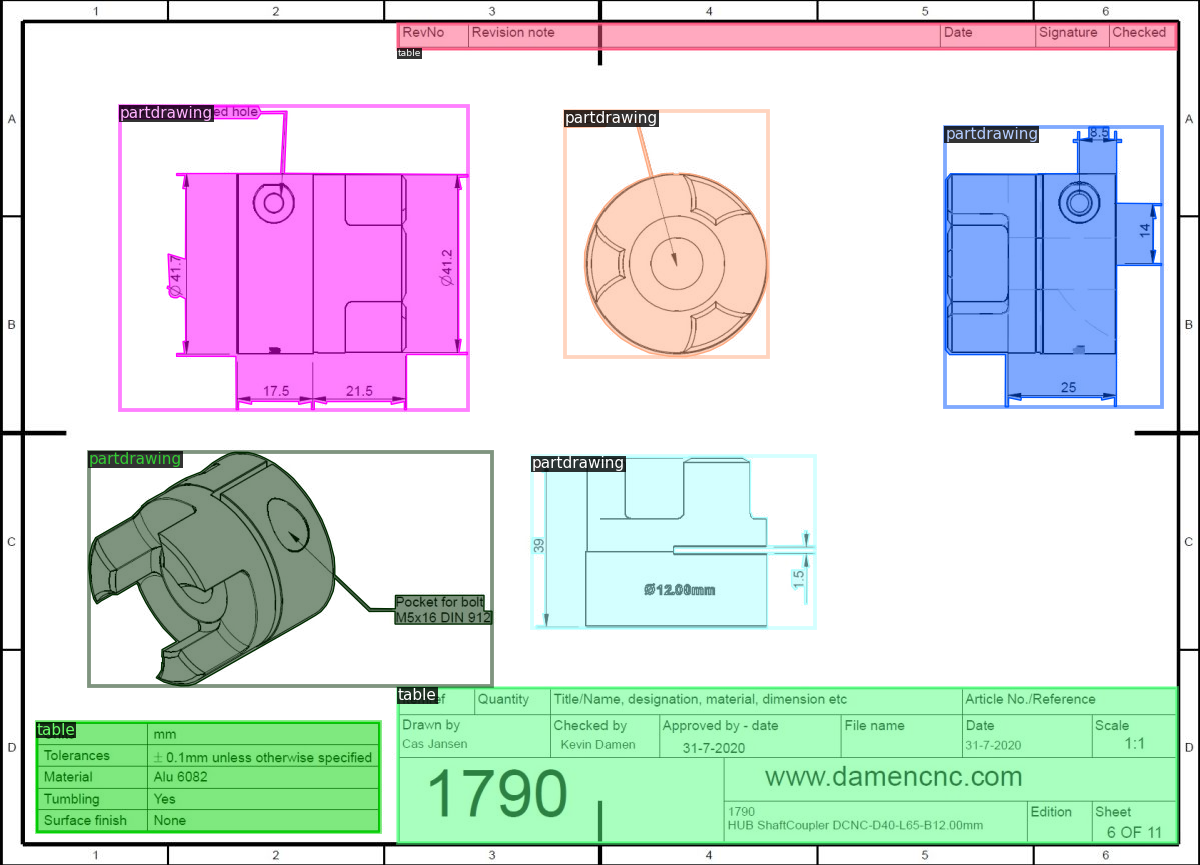

In [7]:
import cv2
import random

from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer, ColorMode
from google.colab.patches import cv2_imshow


# =========================
# 1. LOAD DATASET
# =========================
dataset_dicts = DatasetCatalog.get("bom_train")
metadata = MetadataCatalog.get("bom_train")


# =========================
# 2. PICK RANDOM SAMPLE
# =========================
for d in random.sample(dataset_dicts, 1):

    # =========================
    # 3. READ IMAGE
    # =========================
    img = cv2.imread(d["file_name"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    # =========================
    # 4. VISUALIZE GT ANNOTATIONS
    # =========================
    v = Visualizer(
        img,
        metadata=metadata,
        instance_mode=ColorMode.SEGMENTATION  # show GT MASK
    )

    out = v.draw_dataset_dict(d)


    # =========================
    # 5. SHOW
    # =========================
    cv2_imshow(out.get_image()[:, :, ::-1])

#Augmentation

In [8]:
from detectron2.data import transforms as T

augs = [
    T.RandomFlip(prob=0.5, horizontal=True),
    # T.RandomBrightness(0.9, 1.1),
    T.RandomContrast(0.9, 1.1),
    # T.RandomSaturation(0.9, 1.1),
    # T.RandomRotation(angle=[-2, 2]),
]

In [9]:
import numpy as np
import torch
from detectron2.structures import BitMasks, polygons_to_bitmask
from detectron2.data import detection_utils as utils
from detectron2.data import transforms as T

def custom_mapper(dataset_dict):
    dataset_dict = dataset_dict.copy()
    image = utils.read_image(dataset_dict["file_name"], format="BGR")

    # 1. Augmentations
    auginput = T.AugInput(image)
    transforms = T.AugmentationList(augs)(auginput) # Đảm bảo 'augs' đã định nghĩa
    image = auginput.image

    # 2. Transform annotations
    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2])
        for obj in dataset_dict.pop("annotations")
        if obj.get("iscrowd", 0) == 0
    ]

    # 3. Convert sang Instances (Lúc này gt_masks vẫn là PolygonMasks)
    instances = utils.annotations_to_instances(annos, image.shape[:2])

    # 4. QUAN TRỌNG: Filter empty instances TRƯỚC khi convert sang Tensor
    instances = utils.filter_empty_instances(instances)

    # 5. Chuyển đổi sang Bitmask Tensor cho Mask2Former
    if hasattr(instances, "gt_masks"):
        polygons = instances.gt_masks.polygons
        height, width = image.shape[:2]

        bitmasks = []
        for per_instance_polygons in polygons:
            mask = polygons_to_bitmask(per_instance_polygons, height, width)
            bitmasks.append(mask)

        if len(bitmasks) > 0:
            # Mask2Former yêu cầu Tensor (N, H, W)
            instances.gt_masks = torch.stack([torch.from_numpy(x) for x in bitmasks])
        else:
            instances.gt_masks = torch.empty((0, height, width), dtype=torch.uint8)

    # 6. Chuẩn bị đầu ra
    dataset_dict["image"] = torch.as_tensor(
        image.transpose(2, 0, 1).astype("float32")
    )
    dataset_dict["instances"] = instances

    return dataset_dict

In [10]:
from detectron2.data import build_detection_train_loader
from detectron2.engine import DefaultTrainer

class MyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=custom_mapper)

#Training

In [12]:
from detectron2.engine import DefaultTrainer
from detectron2.data import transforms as T
import warnings
warnings.simplefilter("ignore", FutureWarning)

# 1. Model + weight + dataset
cfg = get_cfg()

# mask2former config
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

cfg.merge_from_file("Mask2Former/configs/coco/instance-segmentation/swin/maskformer2_swin_small_bs16_50ep.yaml")
cfg.MODEL.WEIGHTS = ("https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_small_bs16_50ep/model_final_1e7f22.pkl")

cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON = True
cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON = False
cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON = False

cfg.DATASETS.TRAIN = ("bom_train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = True

cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = 3

cfg.MODEL.MASK_FORMER.NUM_OBJECT_QUERIES = 100

cfg.SOLVER.CLIP_GRADIENTS.ENABLED = True
cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE = "norm"
cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE = 1.0
cfg.SOLVER.CLIP_GRADIENTS.NORM_TYPE = 2.0

# 5. Backbone
# cfg.MODEL.BACKBONE.FREEZE_AT = 2

# 6. Input resize
cfg.INPUT.MIN_SIZE_TRAIN = (800, 1000, 1200)
cfg.INPUT.MAX_SIZE_TRAIN = 2000

# cfg.INPUT.MIN_SIZE_TEST = 1000
# cfg.INPUT.MAX_SIZE_TEST = 2000

# 7. training strategy
cfg.SOLVER.IMS_PER_BATCH = 1
cfg.SOLVER.BASE_LR = 0.00003  # pick a good LR
cfg.SOLVER.MAX_ITER = 20000
# cfg.SOLVER.MAX_ITER = 100
cfg.SOLVER.STEPS = [15000, 18000]
cfg.SOLVER.GAMMA = 0.1
cfg.SOLVER.WARMUP_ITERS = 2000
cfg.SOLVER.OPTIMIZER = "ADAMW"
cfg.SOLVER.WEIGHT_DECAY = 0.05
cfg.SOLVER.AMP.ENABLED = True

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
# mask threshold
cfg.MODEL.MASK_FORMER.TEST.OBJECT_MASK_THRESHOLD = 0.5
cfg.MODEL.MASK_FORMER.TEST.OVERLAP_THRESHOLD = 0.8

# 8. Augmentation
# cfg.INPUT.RANDOM_FLIP = "horizontal"

# 9. Debug config
cfg.TEST.EVAL_PERIOD = 500

cfg.OUTPUT_DIR = "/content/drive/MyDrive/output_weight"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = MyTrainer(cfg)

trainer.resume_or_load(resume=False)
trainer.train()

#Result inference visualize function

In [13]:
def result_inference_visualize(instances):
  # LỌC KẾT QUẢ: Mask2Former mặc định trả về 50 queries.
  # Chúng ta chỉ giữ lại những cái có điểm tin cậy cao.
  SCORE_THRESHOLD = 0.5  # Bạn có thể điều chỉnh con số này
  keep = instances.scores > SCORE_THRESHOLD
  filtered_instances = instances[keep]

  print(f"Tổng số detection tìm thấy: {len(instances)}")
  print(f"Số detection sau khi lọc (score > {SCORE_THRESHOLD}): {len(filtered_instances)}")

  # ==========================================
  # 4. VISUALIZATION
  # ==========================================

  from detectron2.structures import Boxes

  v = Visualizer(
      img[:, :, ::-1],
      metadata=metadata,
      scale=1.0,
      instance_mode=ColorMode.IMAGE
  )

  # labels theo score
  labels = []

  for c, s in zip(
      filtered_instances.pred_classes,
      filtered_instances.scores
  ):

      cls_name = (
          class_names[int(c)]
          if class_names
          else f"Class {int(c)}"
      )

      labels.append(f"{cls_name} {float(s):.2f}")

  # masks
  masks = filtered_instances.pred_masks.numpy()

  # ==========================================
  # GENERATE BBOX FROM MASK
  # ==========================================
  boxes = []

  for mask in masks:
      ys, xs = np.where(mask > 0)

      # mask rỗng
      if len(xs) == 0 or len(ys) == 0:
          boxes.append([0, 0, 0, 0])
          continue

      x1 = np.min(xs)
      y1 = np.min(ys)

      x2 = np.max(xs)
      y2 = np.max(ys)

      boxes.append([x1, y1, x2, y2])

  boxes = np.array(boxes)
  # print("boxes ", boxes)

  # convert sang Detectron2 Boxes
  boxes_tensor = Boxes(torch.tensor(boxes))

  # ==========================================
  # DRAW
  # ==========================================
  out = v.overlay_instances(
      boxes=boxes_tensor,
      masks=masks,
      labels=labels,
      alpha=0.45
  )

  result_img = out.get_image()[:, :, ::-1]

  # side by side
  h, w = result_img.shape[:2]
  img_resized = cv2.resize(img, (w, h))
  combined = np.hstack([img_resized, result_img])
  cv2_imshow(combined)

  # ==========================================
  # 5. SHOW LOG
  # ==========================================
  print(f"\nHiển thị {len(filtered_instances)} đối tượng kèm Bounding Box và Mask:\n")

  for i in range(len(filtered_instances)):
      score = filtered_instances.scores[i].item()
      cls_id = filtered_instances.pred_classes[i].item()

      name = (
          class_names[cls_id]
          if class_names
          else f"Class {cls_id}"
      )

      # dùng boxes generate từ mask
      x1, y1, x2, y2 = boxes[i]

      print(
          f"Object {i+1}: "
          f"{name} | "
          f"Score: {score:.4f} | "
          f"Box: [{x1}, {y1}, {x2}, {y2}]"
      )

#Single model inference

In [14]:
import os
import cv2
import torch
import numpy as np
from google.colab.patches import cv2_imshow

# Detectron2 imports
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog

# Mask2Former imports
from detectron2.projects.deeplab import add_deeplab_config
from Mask2Former.mask2former import add_maskformer2_config

# ==========================================
# 1. SETUP METADATA (Đảm bảo trùng với lúc train)
# ==========================================
# Nếu bạn đã đăng ký dataset trước đó, hãy lấy lại metadata
# Ở đây tôi giả định bạn đã có thing_classes cho "bom_train"
DatasetCatalog.get("bom_train")
metadata = MetadataCatalog.get("bom_train")
class_names = getattr(metadata, "thing_classes", None)

# ==========================================
# 2. CONFIGURATION
# ==========================================
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

# Load file config gốc của Swin Tiny
cfg.merge_from_file("Mask2Former/configs/coco/instance-segmentation/swin/maskformer2_swin_small_bs16_50ep.yaml")

# Đường dẫn trọng số đã train của bạn
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/output_weight/model_final.pth"

# Số lượng class (phải khớp với model_final.pth)
cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = 3

# Thiết lập chế độ Inference
cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON = True
cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON = False
cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON = False

# Tăng độ phân giải test để không bị mất chi tiết bản vẽ mảnh
cfg.INPUT.MIN_SIZE_TEST = 1000
cfg.INPUT.MAX_SIZE_TEST = 2000

cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Khởi tạo Predictor
predictor = DefaultPredictor(cfg)

[05/17 09:57:41 d2.data.datasets.coco]: Loaded 58 images in COCO format from /content/bom_set/instances_Train2.json
[05/17 09:57:42 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/output_weight/model_final.pth ...


##Inference + Visualize

Tổng số detection tìm thấy: 100
Số detection sau khi lọc (score > 0.5): 8


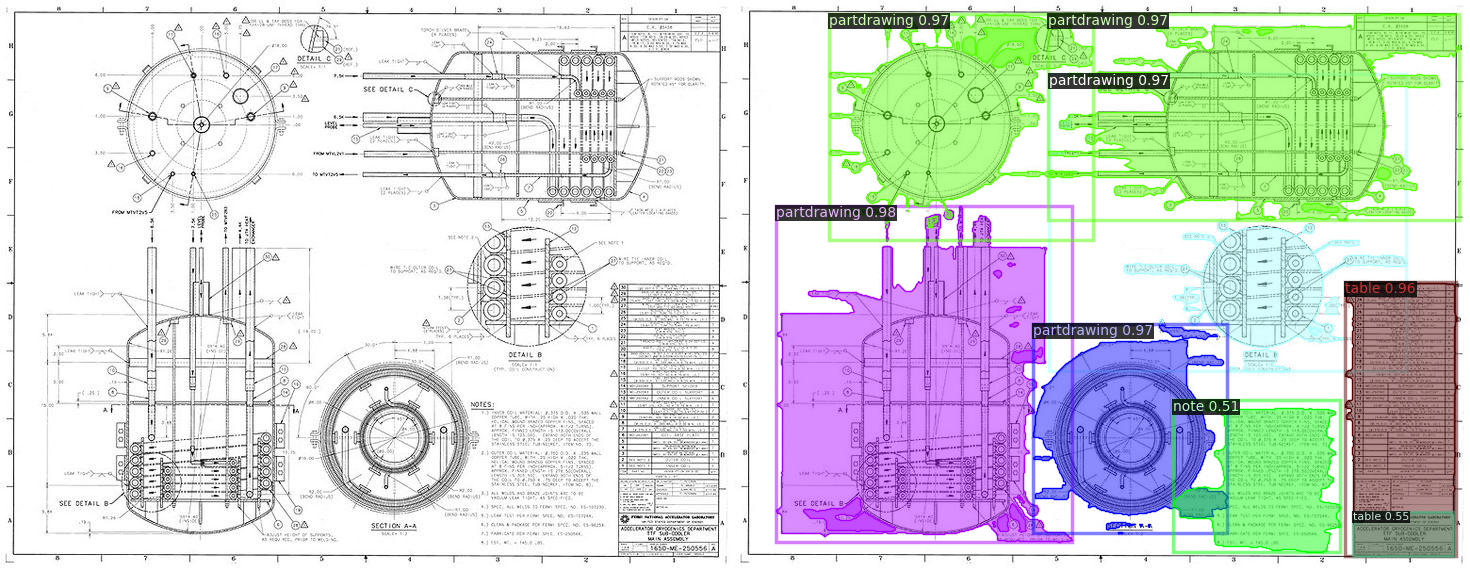


Hiển thị 8 đối tượng kèm Bounding Box và Mask:

Object 1: table | Score: 0.5509 | Box: [618, 512, 718, 556]
Object 2: table | Score: 0.9606 | Box: [610, 282, 721, 556]
Object 3: partdrawing | Score: 0.9691 | Box: [314, 74, 671, 371]
Object 4: partdrawing | Score: 0.9739 | Box: [313, 14, 724, 220]
Object 5: partdrawing | Score: 0.9753 | Box: [41, 206, 337, 542]
Object 6: partdrawing | Score: 0.9742 | Box: [94, 14, 358, 240]
Object 7: note | Score: 0.5050 | Box: [438, 400, 605, 552]
Object 8: partdrawing | Score: 0.9721 | Box: [298, 324, 492, 533]


In [15]:
img_path = "/content/bom_set/test_set/1f9993cf9b67e4422802ca5c4650e878.jpg"
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh tại: {img_path}")

outputs = predictor(img)
instances = outputs["instances"].to("cpu")

result_inference_visualize(instances)

#Code-Helper

In [16]:
def mask_iou(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return inter / (union + 1e-6)

In [17]:
def mask_nms(
    masks,
    scores,
    classes,
    iou_thresh=0.5,
):
    scores_np = scores.cpu().numpy()
    classes_np = classes.cpu().numpy()
    order = scores_np.argsort()[::-1]
    keep = []
    while len(order) > 0:
        i = order[0]
        keep.append(i)
        remain = []
        for j in order[1:]:
            if classes_np[i] != classes_np[j]:
                remain.append(j)
                continue

            iou = mask_iou(masks[i], masks[j])

            if iou < iou_thresh:
                remain.append(j)

        order = np.array(remain)
    return keep

In [18]:
def refine_single_mask(
    mask,
    kernel_size=3,
    dilate_iter=1,
):
    """
    Refine thin technical drawing masks.
    """

    mask_u8 = (mask.astype(np.uint8)) * 255

    kernel = cv2.getStructuringElement(
        cv2.MORPH_CROSS,
        (kernel_size, kernel_size),
    )

    # close small gaps
    refined = cv2.morphologyEx(
        mask_u8,
        cv2.MORPH_CLOSE,
        kernel,
    )

    # preserve thin lines
    refined = cv2.dilate(
        refined,
        kernel,
        iterations=dilate_iter,
    )

    return refined > 0

In [19]:
def masks_to_boxes(masks):
    boxes = []
    for mask in masks:
        ys, xs = np.where(mask > 0)
        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0, 0, 0, 0])
        else:
            boxes.append(
                [
                    np.min(xs),
                    np.min(ys),
                    np.max(xs),
                    np.max(ys),
                ]
            )

    return np.array(boxes)

#TTA + Inference

In [20]:
import torch
import numpy as np
import cv2

from detectron2.structures import Instances, Boxes
from detectron2.layers import batched_nms

def tta_inference(
    predictor,
    image,
    scales=[1600],
    flip=True,
    score_thresh=0.5,
):
    h0, w0 = image.shape[:2]

    all_boxes = []
    all_scores = []
    all_classes = []
    all_masks = []

    for scale in scales:
        scale_factor = scale / min(h0, w0)
        new_h = int(h0 * scale_factor)
        new_w = int(w0 * scale_factor)

        resized = cv2.resize(image, (new_w, new_h))

        augmentations = [(resized, False)]

        if flip:
            augmentations.append((cv2.flip(resized, 1), True))

        for aug_img, is_flipped in augmentations:
            outputs = predictor(aug_img)
            inst = outputs["instances"].to("cpu")

            if len(inst) == 0:
                continue

            keep = inst.scores > score_thresh
            inst = inst[keep]

            if len(inst) == 0:
                continue

            # ================= BOX =================
            boxes = inst.pred_boxes.tensor.numpy()

            if is_flipped:
                x1 = boxes[:, 0].copy()
                x2 = boxes[:, 2].copy()
                boxes[:, 0] = new_w - x2
                boxes[:, 2] = new_w - x1

            # scale back về ảnh gốc
            boxes[:, [0, 2]] *= (w0 / new_w)
            boxes[:, [1, 3]] *= (h0 / new_h)

            # ================= MASK =================
            masks = inst.pred_masks.numpy()
            restored_masks = []

            for m in masks:
                if is_flipped:
                    m = np.fliplr(m)

                m = cv2.resize(
                    m.astype(np.uint8),
                    (w0, h0),
                    interpolation=cv2.INTER_NEAREST,
                )

                restored_masks.append(m.astype(bool))

            # ================= MERGE =================
            all_boxes.extend(boxes)
            all_scores.extend(inst.scores.numpy())
            all_classes.extend(inst.pred_classes.numpy())
            all_masks.extend(restored_masks)

    return {
        "boxes": np.array(all_boxes),
        "scores": np.array(all_scores),
        "classes": np.array(all_classes),
        "masks": np.array(all_masks),
    }

In [21]:
def inference_with_tta(
    predictor,
    image,
    scales=[1600],
    flip=True,
    score_thresh=0.5,
    box_nms_thresh=0.4,
    mask_nms_thresh=0.4,
    max_detections=50,
):
    h, w = image.shape[:2]

    result = tta_inference(
        predictor,
        image,
        scales=scales,
        flip=flip,
        score_thresh=score_thresh,
    )

    if len(result["boxes"]) == 0:
        return Instances((h, w))

    boxes = torch.tensor(result["boxes"]).float()
    scores = torch.tensor(result["scores"])
    classes = torch.tensor(result["classes"])
    masks = result["masks"]

    # ================= BOX NMS =================
    keep = batched_nms(
        boxes,
        scores,
        classes,
        box_nms_thresh
    )

    keep = keep[:max_detections]

    boxes = boxes[keep]
    scores = scores[keep]
    classes = classes[keep]
    masks = masks[keep.numpy()]

    # ================= MASK NMS =================
    keep_mask = mask_nms(
        masks,
        scores,
        classes,
        iou_thresh=mask_nms_thresh
    )

    keep_mask = keep_mask[:max_detections]

    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    classes = classes[keep_mask]
    masks = masks[keep_mask]

    # ================= FINAL INSTANCES =================
    instances = Instances((h, w))
    instances.pred_boxes = Boxes(boxes)
    instances.scores = scores
    instances.pred_classes = classes
    instances.pred_masks = torch.from_numpy(masks)

    return instances

##Inference + Visualize

Tổng số detection tìm thấy: 9
Số detection sau khi lọc (score > 0.5): 9


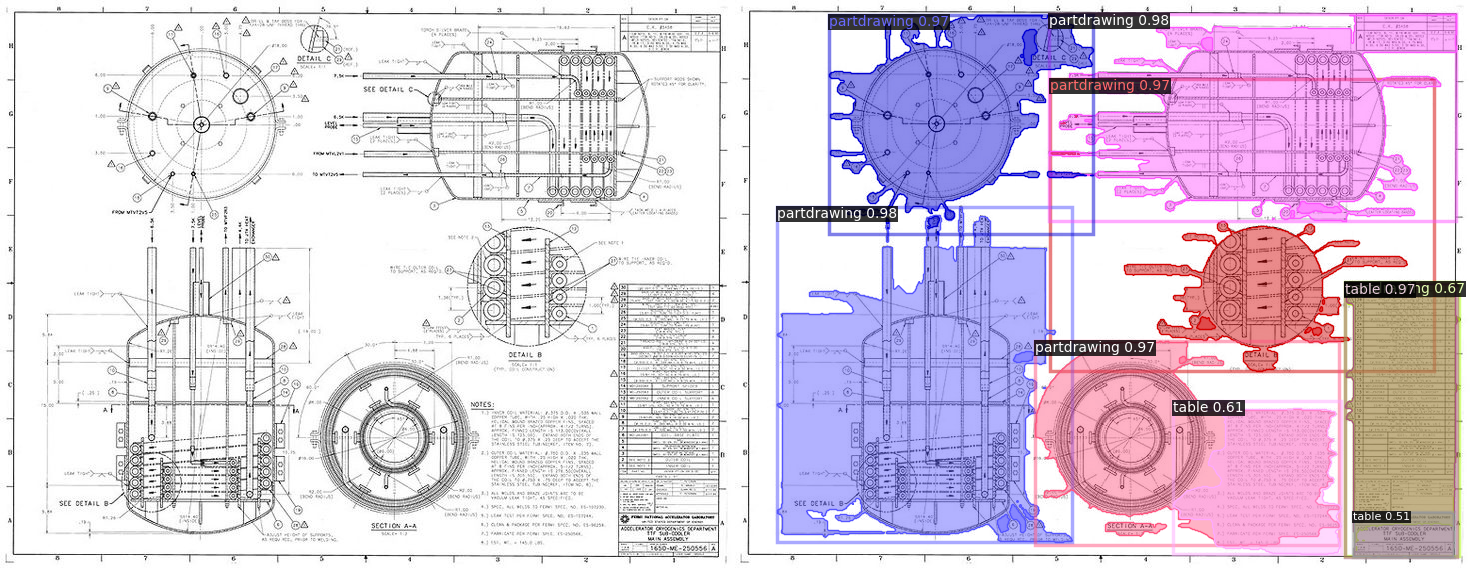


Hiển thị 9 đối tượng kèm Bounding Box và Mask:

Object 1: partdrawing | Score: 0.9794 | Box: [42, 207, 337, 542]
Object 2: partdrawing | Score: 0.9756 | Box: [314, 14, 721, 221]
Object 3: partdrawing | Score: 0.9729 | Box: [300, 341, 604, 545]
Object 4: partdrawing | Score: 0.9722 | Box: [315, 79, 699, 371]
Object 5: partdrawing | Score: 0.9720 | Box: [94, 15, 358, 234]
Object 6: table | Score: 0.9675 | Box: [610, 283, 722, 557]
Object 7: partdrawing | Score: 0.6671 | Box: [610, 282, 724, 556]
Object 8: table | Score: 0.6062 | Box: [438, 401, 606, 554]
Object 9: table | Score: 0.5051 | Box: [618, 512, 719, 557]


In [22]:
img_path = "/content/bom_set/test_set/1f9993cf9b67e4422802ca5c4650e878.jpg"
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh tại: {img_path}")

instances = inference_with_tta(
    predictor,
    img,
    scales=[1600],  # có thể thêm multi-scale
    flip=True,
    score_thresh=0.5,
)

result_inference_visualize(instances)

#TTA + ensemble + inference

In [23]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.projects.deeplab import add_deeplab_config
from Mask2Former.mask2former import add_maskformer2_config

def build_predictor(config_path, weight_path):
    cfg = get_cfg()
    add_deeplab_config(cfg)
    add_maskformer2_config(cfg)

    cfg.merge_from_file(config_path)
    cfg.MODEL.WEIGHTS = weight_path
    cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = 3
    cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON = True
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
    cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    predictor = DefaultPredictor(cfg)

    return predictor

In [24]:
predictor_tiny_10k = build_predictor(
    "/content/Mask2Former/configs/coco/instance-segmentation/swin/maskformer2_swin_tiny_bs16_50ep.yaml",
    "/content/model_weight/tiny_10k.pth",
)

predictor_tiny = build_predictor(
    "/content/Mask2Former/configs/coco/instance-segmentation/swin/maskformer2_swin_tiny_bs16_50ep.yaml",
    "/content/model_weight/tiny_20k.pth",
)

predictor_small = build_predictor(
    "/content/Mask2Former/configs/coco/instance-segmentation/swin/maskformer2_swin_small_bs16_50ep.yaml",
    "/content/model_weight/small_20k.pth",
)

MODELS = [
    {
        "predictor": predictor_tiny_10k,
        "weight": 1,                                # define weight of each model's predict
    },
    {
        "predictor": predictor_tiny,
        "weight": 1,
    },
    {
        "predictor": predictor_small,
        "weight": 1,
    },
]

[05/17 09:58:25 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/model_weight/tiny_10k.pth ...
[05/17 09:58:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/model_weight/tiny_20k.pth ...
[05/17 09:58:30 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/model_weight/small_20k.pth ...


In [25]:
def ensemble_inference(
    image,
    scales=[1600],
    flip=True,
    score_thresh=0.5,
    box_nms_thresh=0.4,
    mask_nms_thresh=0.4,
    max_detections=50,
):

    h0, w0 = image.shape[:2]

    all_boxes = []
    all_scores = []
    all_classes = []
    all_masks = []

    # =====================================================
    # RUN ALL MODELS
    # =====================================================
    for model_data in MODELS:
        predictor = model_data["predictor"]
        model_weight = model_data["weight"]

        result = tta_inference(
            predictor=predictor,
            image=image,
            scales=scales,
            flip=flip,
            score_thresh=score_thresh,
        )

        if len(result["boxes"]) == 0:
            continue

        all_boxes.extend(result["boxes"])

        weighted_scores = [
            min(s * model_weight, 1.0)
            for s in result["scores"]
        ]

        all_scores.extend(weighted_scores)
        all_classes.extend(result["classes"])
        all_masks.extend(result["masks"])

    # =====================================================
    # EMPTY
    # =====================================================
    if len(all_boxes) == 0:
        return Instances((h0, w0))

    # =====================================================
    # TO TENSOR
    # =====================================================
    all_boxes = torch.tensor(np.array(all_boxes))
    all_scores = torch.tensor(np.array(all_scores))
    all_classes = torch.tensor(np.array(all_classes))

    # =====================================================
    # BOX NMS
    # =====================================================
    keep_box = batched_nms(
        all_boxes,
        all_scores,
        all_classes,
        box_nms_thresh,
    )

    if len(keep_box) == 0:
        return Instances((h0, w0))

    kept_masks = [
        all_masks[i]
        for i in keep_box.numpy()
    ]

    kept_scores = all_scores[keep_box].numpy()

    # =====================================================
    # MASK NMS
    # =====================================================
    keep_mask = mask_nms(
        kept_masks,
        all_scores[keep_box],
        all_classes[keep_box],
        iou_thresh=mask_nms_thresh,
    )

    if len(keep_mask) == 0:
        return Instances((h0, w0))

    keep_mask = keep_mask[:max_detections]

    # =====================================================
    # FINAL SELECTED
    # =====================================================
    final_masks = [
        kept_masks[i]
        for i in keep_mask
    ]

    # final_scores = [
    #     kept_scores[i]
    #     for i in keep_mask
    # ]

    final_boxes = all_boxes[keep_box][keep_mask]
    final_scores_tensor = all_scores[keep_box][keep_mask]
    final_classes = all_classes[keep_box][keep_mask]

    # =====================================================
    # POST-PROCESSING
    # =====================================================

    # 1. Refine each mask
    refined_masks = []
    for mask in final_masks:
        # refined = refine_single_mask(
        #     mask,
        #     eps=15,
        #     min_samples=2,
        # )
        refined = refine_single_mask(mask)
        # refined = mask

        refined_masks.append(refined)
    refined_masks = np.array(refined_masks)
    resolved_masks = refined_masks

    # =====================================================
    # 3. Recompute boxes from refined masks
    # =====================================================
    refined_boxes = masks_to_boxes(
        resolved_masks
    )

    # =====================================================
    # FINAL INSTANCES
    # =====================================================
    final = Instances((h0, w0))
    final.pred_boxes = Boxes(
        torch.tensor(refined_boxes).float()
    )
    final.scores = final_scores_tensor
    final.pred_classes = final_classes
    final.pred_masks = torch.from_numpy(
        resolved_masks
    )
    return final

##Inference + Visualize

Tổng số detection tìm thấy: 10
Số detection sau khi lọc (score > 0.5): 10


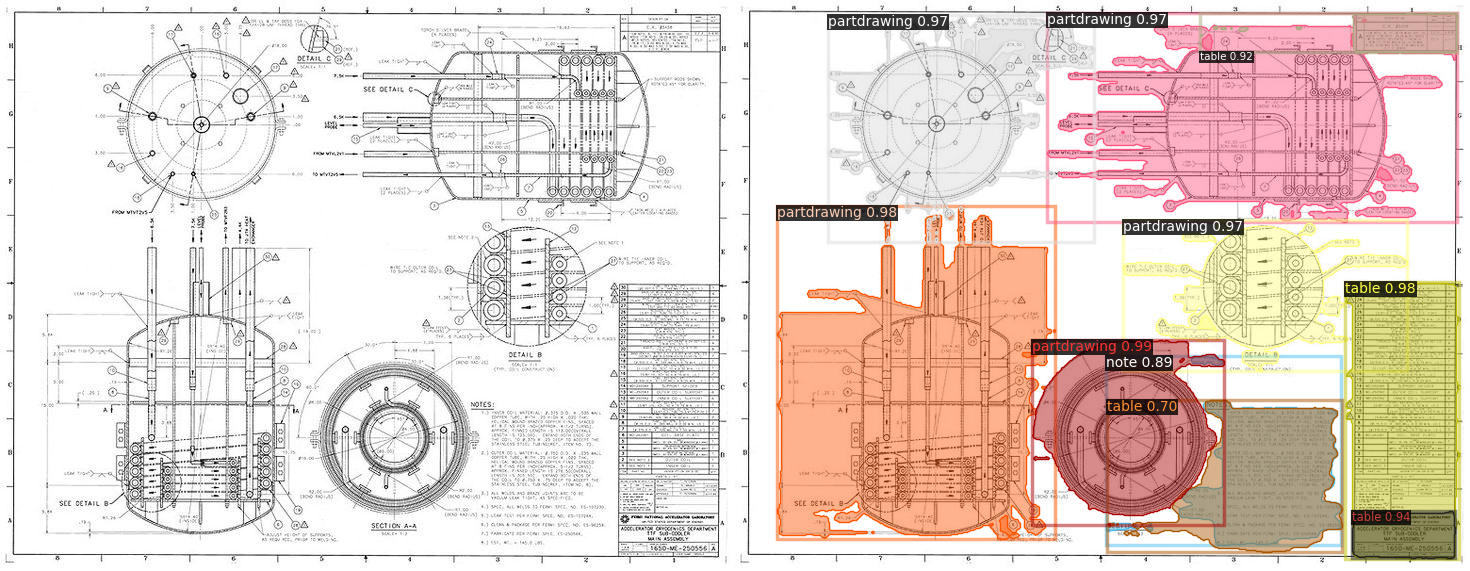


Hiển thị 10 đối tượng kèm Bounding Box và Mask:

Object 1: partdrawing | Score: 0.9897 | Box: [297, 340, 489, 525]
Object 2: partdrawing | Score: 0.9844 | Box: [42, 206, 320, 539]
Object 3: table | Score: 0.9825 | Box: [610, 282, 724, 559]
Object 4: partdrawing | Score: 0.9739 | Box: [93, 15, 359, 242]
Object 5: partdrawing | Score: 0.9733 | Box: [388, 220, 672, 371]
Object 6: partdrawing | Score: 0.9675 | Box: [312, 13, 722, 222]
Object 7: table | Score: 0.9413 | Box: [617, 511, 720, 558]
Object 8: table | Score: 0.9203 | Box: [465, 13, 722, 52]
Object 9: note | Score: 0.8883 | Box: [371, 356, 606, 545]
Object 10: table | Score: 0.7045 | Box: [372, 400, 607, 552]


In [27]:
img_path = "/content/bom_set/test_set/1f9993cf9b67e4422802ca5c4650e878.jpg"
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh tại: {img_path}")

instances = ensemble_inference(
    img,
    scales=[1600],
    flip=True,
    score_thresh=0.5,
    box_nms_thresh=0.4,
    mask_nms_thresh=0.4,
    max_detections=50,
)

result_inference_visualize(instances)